# Parte 3 — Ablação, Eixo 1: a célula recorrente

**A pergunta do eixo**: RNN simples vs. LSTM vs. GRU, no mesmo orçamento aproximado de parâmetros, variando também o comprimento da janela de BPTT truncado ($T \in \{4, 8, 16, 32\}$). Onde a RNN simples quebra, e isso bate com a história do gradiente que some contada na aula?

**Por que este eixo.** A Parte 2 terminou com uma GRU que prevê a caixa melhor que o Kalman até ~15 quadros sem observação, mas que não converte isso em IDF1. Antes de mexer no regime de treino ou na entrada, vale saber se a **memória** em si é o que está trabalhando: uma RNN simples, que não tem portas, deveria ter o mesmo desempenho onde a previsão só precisa do passado imediato e quebrar onde ela precisa atravessar um buraco longo. Este eixo também prepara a Parte 4, que pede a curva de $\|\partial \mathcal{L}_t / \partial h_{t-k}\|$ "da RNN simples com a do modelo com portas, na mesma janela" — os checkpoints ficam em `results/3_ablation/`.

**O que é fixo** (o pipeline da Parte 2, `src/nn/experiments.py`):

- dados: trajetórias do GT das 5 sequências de treino como alvo, **detecções reais do SDP** como entrada, blocos de ausência de 1–40 quadros (p = 0,3), janelas de **64 quadros** — mais longas que a maior janela de BPTT, para que $T = 32$ também seja truncamento;
- treino: smooth-L1 nos deslocamentos, Adam (3·10⁻³) com decaimento cosseno, 12 épocas, scheduled sampling 0 → 0,5, *clipping* em norma 1;
- rastreamento: a regra da GRU da Parte 2 (Hungarian, IoU ≥ 0,3, `max_age` = 40), nas 7 sequências.

**O que varia**: a célula (com o hidden size ajustado ao orçamento da GRU de 64 unidades: 13,8 mil parâmetros na célula), $T$ e a seed (0, 1, 2 — inicialização, ordem das janelas, blocos de ausência e sorteios do scheduled sampling). A validação é a **mesma** janela fixa para todas as rodadas.

**BPTT truncado**: cada janela de 64 quadros é processada em blocos de $T$ passos; o estado (e a última entrada/previsão) atravessa de um bloco para o seguinte, mas **destacado do grafo** — o gradiente da perda no passo $t$ não chega a nada antes do início do bloco. Com $T = 4$, nenhum sinal de supervisão atravessa mais de 4 quadros.

**Uma sonda além da grade** (seção 5): o mesmo treino, mudando só o que entra no modelo durante a oclusão — a última caixa observada, congelada, em vez da própria previsão. É a versão do problema em que a velocidade **tem** de atravessar o buraco dentro do estado; serve para separar "a RNN simples não quebra porque a tarefa não exige memória longa" de "a RNN simples não quebra nunca".

As 36 rodadas da grade (+ 27 da sonda) são treinadas por `python -m src.nn.experiments` (~1 h em CPU com 3 processos em paralelo); se os resultados já existem em `results/3_ablation/`, este notebook só agrega.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.dataset.mot17 import SPLIT
from src.nn.experiments import (MotionData, run_config, K_BINS, k_label, iou_by_k, PARAM_BUDGET, TRACK_CFG, DEFAULTS,
                                INPUT_SIZE)
from src.nn.loss import make_box_loss
from src.nn.models import (MotionModel, load_motion_model, gradient_norm_through_time, steps_since_observation,
                           hidden_size_for_budget, naive_motion_predictions, box_iou_cxcywh)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_DIR = "results"
OUT_DIR = os.path.join(RESULTS_DIR, "3_ablation")

pd.set_option("display.precision", 3)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)

TRAIN, VAL = SPLIT["train"], SPLIT["val"]
CELLS = ["rnn", "lstm", "gru"]
CELL_NAMES = {"rnn": "RNN simples", "lstm": "LSTM", "gru": "GRU"}
CELL_COLORS = {"rnn": "tab:red", "lstm": "tab:blue", "gru": "tab:green"}
TBPTT = [4, 8, 16, 32]
PROBE_T = [4, 16, 32]
SEEDS = [0, 1, 2]

data = MotionData(root="../data")

runs = [run_config(data, cell, T, seed, OUT_DIR, device=device)
        for seed in SEEDS for cell in CELLS for T in TBPTT]
probe = [run_config(data, cell, T, seed, OUT_DIR, device=device, coast_input="last_observation")
         for seed in SEEDS for cell in CELLS for T in PROBE_T]

print(f"{len(runs)} rodadas da grade + {len(probe)} da sonda | orçamento de parâmetros da célula: {PARAM_BUDGET}")
print(f"treino: {DEFAULTS} | rastreamento: {TRACK_CFG}")

36 rodadas da grade + 27 da sonda | orçamento de parâmetros da célula: 13824
treino: {'window': 64, 'stride': 32, 'epochs': 12, 'lr': 0.003, 'batch_size': 64, 'sampling_max': 0.5, 'clip_grad': 1.0, 'beta': 0.1, 'occlusion_prob': 0.3, 'occlusion_len': (1, 40)} | rastreamento: {'matching': 'hungarian', 'iou_threshold': 0.3, 'max_age': 40}


## 1. As configurações

In [2]:
configs = (pd.DataFrame([{
    "célula": CELL_NAMES[r["cell"]], "hidden": r["hidden_size"], "parâmetros na célula": r["cell_parameters"],
    "parâmetros totais": r["parameters"], "T": r["tbptt"],
    "min de treino (12 épocas)": r["train_seconds"] / 60,
} for r in runs]).groupby(["célula", "T"]).agg({"hidden": "first", "parâmetros na célula": "first",
                                                 "parâmetros totais": "first", "min de treino (12 épocas)": "mean"}))
print(configs.round(1).to_string())

                hidden  parâmetros na célula  parâmetros totais  min de treino (12 épocas)
célula      T                                                                             
GRU         4       64                 13824              14084                        2.7
            8       64                 13824              14084                        2.5
            16      64                 13824              14084                        2.2
            32      64                 13824              14084                        2.3
LSTM        4       54                 13392              13612                        2.6
            8       54                 13392              13612                        2.4
            16      54                 13392              13612                        2.0
            32      54                 13392              13612                        2.1
RNN simples 4      113                 13673              14129                        2.4

O orçamento é o da GRU da Parte 2 (13.824 parâmetros na célula): a RNN simples, com uma matriz só, fica com 113 unidades; a LSTM, com quatro, com 54. Os totais ficam dentro de 4 % (13,6–14,1 mil). Mais unidades não são vantagem de graça para a RNN: o estado é maior, mas toda a memória passa por uma única matriz e uma tanh. Os tempos de treino (1,5–2,7 min por rodada) foram medidos com vários processos dividindo a CPU — servem só para dizer que as três custam praticamente o mesmo, a RNN um pouco menos.

## 2. O efeito no rastreamento

Para cada rodada: IDF1 médio por sequência no treino e na validação, IDF1 combinado nas 7 sequências e ID switches por identidade verdadeira. Média ± desvio sobre as 3 seeds.

média ± desvio sobre 3 seeds:

                  IDF1 treino       IDF1 val IDF1 combinado      IDSW / id       ids / id
cell        T                                                                            
GRU         4   0.601 ± 0.007  0.536 ± 0.018  0.619 ± 0.008  2.247 ± 0.100  1.611 ± 0.016
            8   0.610 ± 0.006  0.545 ± 0.009  0.628 ± 0.003  2.187 ± 0.136  1.598 ± 0.003
            16  0.606 ± 0.005  0.546 ± 0.009  0.629 ± 0.006  2.158 ± 0.057  1.618 ± 0.049
            32  0.601 ± 0.002  0.543 ± 0.011  0.625 ± 0.005  2.308 ± 0.061  1.651 ± 0.002
LSTM        4   0.606 ± 0.005  0.554 ± 0.012  0.623 ± 0.004  2.154 ± 0.079  1.595 ± 0.018
            8   0.605 ± 0.001  0.569 ± 0.010  0.626 ± 0.001  2.266 ± 0.071  1.571 ± 0.005
            16  0.610 ± 0.001  0.558 ± 0.010  0.625 ± 0.001  2.274 ± 0.048  1.594 ± 0.022
            32  0.604 ± 0.002  0.538 ± 0.009  0.617 ± 0.003  2.372 ± 0.124  1.662 ± 0.019
RNN simples 4   0.598 ± 0.008  0.530 ± 0.007  0.609 ± 0.003  2.193 ± 

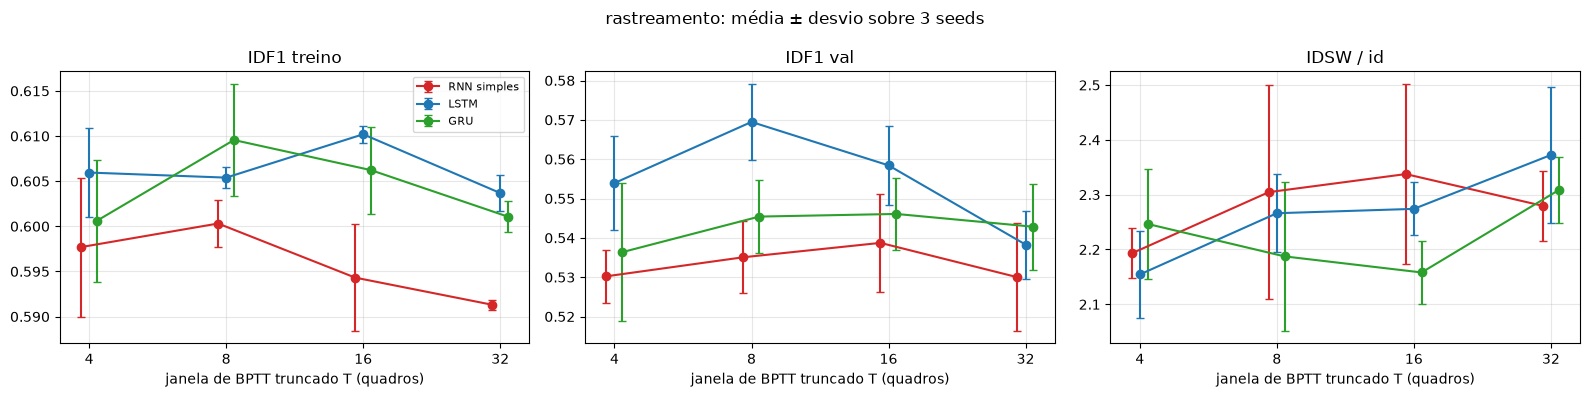

In [3]:
def summarize(r):
    tr = r["tracking"]

    def combined(names):
        idtp = sum(tr[n]["IDTP"] for n in names)
        idfp = sum(tr[n]["IDFP"] for n in names)
        idfn = sum(tr[n]["IDFN"] for n in names)
        return 2 * idtp / (2 * idtp + idfp + idfn)

    row = {
        "cell": r["cell"], "T": r["tbptt"], "seed": r["seed"],
        "IDF1 treino": np.mean([tr[n]["IDF1"] for n in TRAIN]),
        "IDF1 val": np.mean([tr[n]["IDF1"] for n in VAL]),
        "IDF1 combinado": combined(TRAIN + VAL),
        "IDSW / id": sum(tr[n]["IDSW"] for n in TRAIN + VAL) / sum(tr[n]["n_gt_ids"] for n in TRAIN + VAL),
        "ids / id": sum(tr[n]["n_pred_ids"] for n in TRAIN + VAL) / sum(tr[n]["n_gt_ids"] for n in TRAIN + VAL),
        "val loss": r["val_loss"],
    }
    row.update({f"IoU {k}": v for k, v in r["iou_by_k"].items()})
    row.update({f"IDF1 {n}": tr[n]["IDF1"] for n in TRAIN + VAL})
    return row


table = pd.DataFrame([summarize(r) for r in runs])
probe_table = pd.DataFrame([summarize(r) for r in probe])
pd.concat([table.assign(coast_input="prediction"), probe_table.assign(coast_input="last_observation")]).to_csv(
    os.path.join(RESULTS_DIR, "3_ablation_runs.csv"), index=False)


def mean_std(df, cols):
    g = df.groupby(["cell", "T"])[cols]
    m, s = g.mean(), g.std()
    out = m.copy().astype(object)
    for c in cols:
        out[c] = [f"{a:.3f} ± {b:.3f}" for a, b in zip(m[c], s[c])]
    out.index = out.index.set_levels([CELL_NAMES[c] for c in out.index.levels[0]], level=0)
    return out


def errorbar_by_T(ax, df, metric, Ts):
    for cell in CELLS:
        part = df[df.cell == cell].groupby("T")[metric]
        ax.errorbar(np.array(Ts) * (1 + 0.04 * (CELLS.index(cell) - 1)), part.mean().loc[Ts], yerr=part.std().loc[Ts],
                    marker="o", capsize=3, color=CELL_COLORS[cell], label=CELL_NAMES[cell])
    ax.set_xscale("log", base=2)
    ax.set_xticks(Ts, [str(t) for t in Ts])
    ax.set_xlabel("janela de BPTT truncado T (quadros)")
    ax.grid(alpha=0.3)


TRACK_COLS = ["IDF1 treino", "IDF1 val", "IDF1 combinado", "IDSW / id", "ids / id"]
print("média ± desvio sobre 3 seeds:\n")
print(mean_std(table, TRACK_COLS).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["IDF1 treino", "IDF1 val", "IDSW / id"]):
    errorbar_by_T(ax, table, metric, TBPTT)
    ax.set_title(metric)
axes[0].legend(fontsize=8)
fig.suptitle("rastreamento: média ± desvio sobre 3 seeds")
plt.tight_layout()
plt.show()

In [4]:
# A diferença entre células é maior que o ruído entre seeds?
# Para cada T, a diferença de IDF1 combinado entre pares de células, seed a seed
# (mesma seed = mesmos blocos de ausência e mesma ordem das janelas).
def paired(df, metric, Ts):
    rows = []
    for T in Ts:
        part = df[df["T"] == T].pivot(index="seed", columns="cell", values=metric)
        for a, b in [("gru", "rnn"), ("lstm", "rnn"), ("gru", "lstm")]:
            d = part[a] - part[b]
            rows.append({"T": T, "par": f"{CELL_NAMES[a]} − {CELL_NAMES[b]}",
                         "diferença": f"{d.mean():+.3f} ± {d.std():.3f} ({int((d > 0).sum())}/3)"})
    return pd.DataFrame(rows).pivot(index="par", columns="T", values="diferença")


print("IDF1 combinado: diferença média ± desvio entre seeds pareadas (seeds em que o primeiro é melhor)\n")
print(paired(table, "IDF1 combinado", TBPTT).to_string())

IDF1 combinado: diferença média ± desvio entre seeds pareadas (seeds em que o primeiro é melhor)

T                                     4                     8                     16                    32
par                                                                                                       
GRU − LSTM          -0.004 ± 0.007 (1/3)  +0.002 ± 0.002 (2/3)  +0.003 ± 0.006 (2/3)  +0.008 ± 0.007 (3/3)
GRU − RNN simples   +0.010 ± 0.008 (3/3)  +0.015 ± 0.002 (3/3)  +0.017 ± 0.008 (3/3)  +0.013 ± 0.010 (3/3)
LSTM − RNN simples  +0.014 ± 0.000 (3/3)  +0.013 ± 0.003 (3/3)  +0.014 ± 0.002 (3/3)  +0.004 ± 0.005 (2/3)


**No rastreamento, a RNN simples perde pouco, mas sempre.** IDF1 combinado de 0,609–0,613 contra 0,619–0,629 da GRU e 0,617–0,626 da LSTM; em cada $T$ a GRU vence a RNN nas 3 seeds (diferença pareada de +0,010 a +0,017), e a LSTM também até $T = 16$. Entre LSTM e GRU não há diferença acima do ruído (−0,004 a +0,008, com seeds para os dois lados).

Duas coisas **não** aparecem: (i) $T$ quase não importa para o rastreamento — nenhuma célula varia mais de ~0,01 entre $T = 4$ e $T = 32$, o que é 1–2 desvios; (ii) a desvantagem da RNN não depende de $T$, embora (seção 3) a previsão dela em buracos longos dependa muito. O IDF1 de validação, com só 2 sequências, tem desvio de ~0,01 entre seeds e não separa nada. Para referência, a GRU final da Parte 2 fez 0,632 e o Kalman 0,641.

## 3. A previsão do quadro seguinte, por tempo sem observação

O IDF1 mistura tudo. A pergunta do eixo é sobre **memória**, e a medida direta é a da seção 4 da Parte 2: o IoU entre a caixa prevista e a verdadeira, nas janelas fixas de validação, por número de passos $k$ desde a última observação. $k = 0$ só precisa do passado imediato; $k \geq 8$ exige carregar a velocidade através de um buraco.

referências sem aprendizado, nas mesmas janelas:

                          k=0    k=1  k=2-3  k=4-7  k=8-15  k=16-31  k=32-63
última caixa observada  0.786  0.660  0.569  0.436   0.271    0.140    0.077
velocidade constante    0.740  0.609  0.530  0.401   0.227    0.106    0.061

IoU médio da previsão (média ± desvio sobre 3 seeds):

                      IoU k=0        IoU k=1      IoU k=2-3      IoU k=4-7     IoU k=8-15    IoU k=16-31    IoU k=32-63
cell        T                                                                                                          
GRU         4   0.806 ± 0.001  0.690 ± 0.001  0.616 ± 0.004  0.502 ± 0.001  0.345 ± 0.008  0.190 ± 0.008  0.082 ± 0.005
            8   0.806 ± 0.000  0.690 ± 0.001  0.615 ± 0.001  0.504 ± 0.001  0.344 ± 0.004  0.190 ± 0.003  0.083 ± 0.004
            16  0.805 ± 0.001  0.691 ± 0.002  0.615 ± 0.003  0.504 ± 0.002  0.346 ± 0.001  0.193 ± 0.007  0.081 ± 0.002
            32  0.806 ± 0.001  0.689 ± 0.000  0.614 ± 0.001  0.

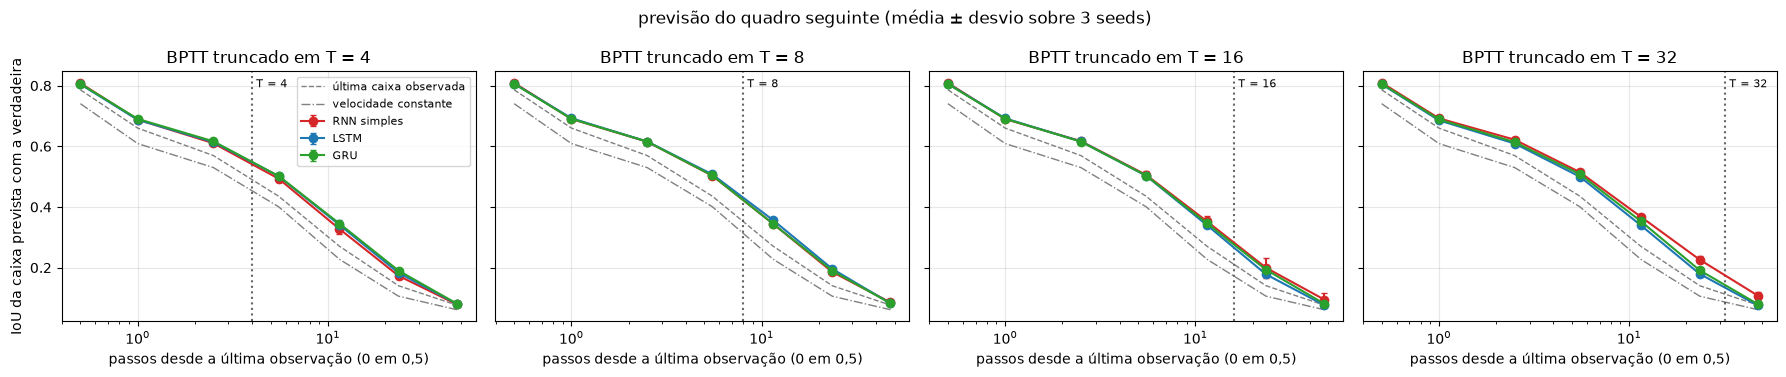

In [5]:
IOU_COLS = [f"IoU {k_label(lo, hi)}" for lo, hi in K_BINS]
XS = [max((lo + hi) / 2, 0.5) for lo, hi in K_BINS]


def naive_iou_by_k(kind):
    ks, ious = [], []
    for b in data.val_loader():
        pred = naive_motion_predictions(b["inputs"], b["observed"], kind=kind)
        m = b["valid"][:, 1:] > 0.5
        ks.append(steps_since_observation(b["observed"])[:, :-1][m].numpy())
        ious.append(box_iou_cxcywh(pred[:, :-1], b["boxes"][:, 1:])[m].numpy())
    return iou_by_k(np.concatenate(ks), np.concatenate(ious))


REF = {"última caixa observada": naive_iou_by_k("static"), "velocidade constante": naive_iou_by_k("velocity")}
REF_STYLE = {"última caixa observada": "--", "velocidade constante": "-."}

print("referências sem aprendizado, nas mesmas janelas:\n")
print(pd.DataFrame(REF).T[[k_label(lo, hi) for lo, hi in K_BINS]].round(3).to_string())
print("\nIoU médio da previsão (média ± desvio sobre 3 seeds):\n")
print(mean_std(table, IOU_COLS).to_string())


def iou_panels(df, Ts, title, ref=None):
    fig, axes = plt.subplots(1, len(Ts), figsize=(4.5 * len(Ts), 3.8), sharey=True)
    for ax, T in zip(axes, Ts):
        for cell in CELLS:
            part = df[(df.cell == cell) & (df["T"] == T)][IOU_COLS]
            ax.errorbar(XS, part.mean(), yerr=part.std(), marker="o", capsize=2, color=CELL_COLORS[cell],
                        label=CELL_NAMES[cell])
            if ref is not None:
                base = ref[(ref.cell == cell) & (ref["T"] == T)][IOU_COLS]
                ax.plot(XS, base.mean(), color=CELL_COLORS[cell], linestyle=":", alpha=0.6)
        for name, style in REF_STYLE.items():
            ax.plot(XS, [REF[name][k_label(lo, hi)] for lo, hi in K_BINS], color="gray", linestyle=style, lw=1,
                    label=name)
        ax.axvline(T, color="k", linestyle=":", alpha=0.6)
        ax.text(T * 1.05, 0.97, f"T = {T}", fontsize=8, va="top", transform=ax.get_xaxis_transform())
        ax.set_xscale("log")
        ax.set_xlabel("passos desde a última observação (0 em 0,5)")
        ax.set_title(f"BPTT truncado em T = {T}")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("IoU da caixa prevista com a verdadeira")
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


iou_panels(table, TBPTT, "previsão do quadro seguinte (média ± desvio sobre 3 seeds)")

**Até 3 quadros sem observação, as três células são a mesma coisa** (IoU 0,804–0,810 a partir de uma detecção, 0,686–0,692 após 1 quadro), todas bem acima das referências sem aprendizado (última caixa: 0,786 e 0,660). A RNN simples é até marginalmente a melhor em $k = 0$ (0,808–0,810 contra 0,804–0,806, com desvios de 0,001): prever o próximo quadro a partir de uma detecção só precisa do passado imediato, e isso uma recorrência sem portas faz bem. As diferenças só aparecem em coasting longo — e não na direção que a história do gradiente sugere.

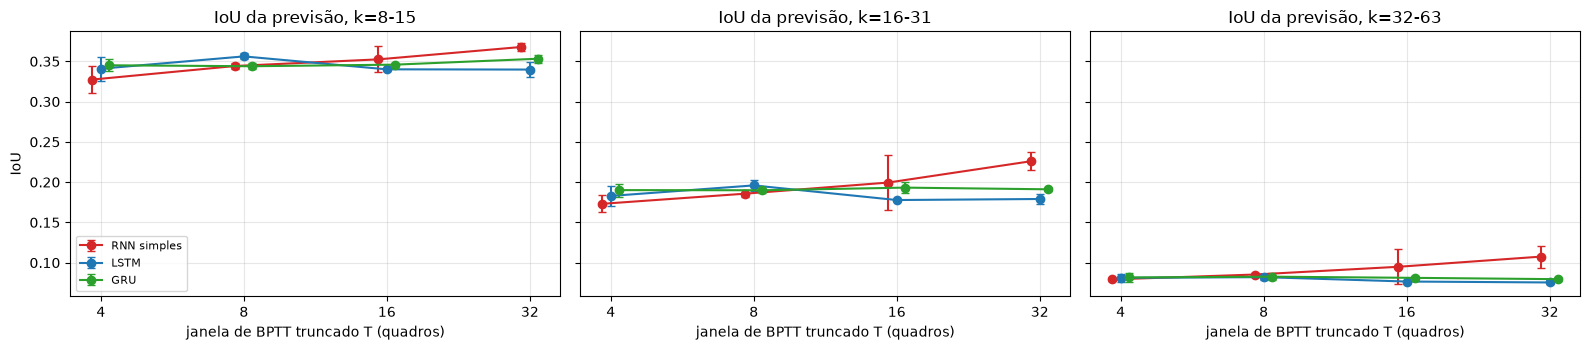

IoU em k = 16-31: diferença média ± desvio entre seeds pareadas

T                                     4                     8                     16                    32
par                                                                                                       
GRU − LSTM          +0.007 ± 0.005 (3/3)  -0.006 ± 0.009 (1/3)  +0.015 ± 0.006 (3/3)  +0.012 ± 0.005 (3/3)
GRU − RNN simples   +0.017 ± 0.003 (3/3)  +0.004 ± 0.006 (2/3)  -0.006 ± 0.028 (2/3)  -0.035 ± 0.013 (0/3)
LSTM − RNN simples  +0.010 ± 0.003 (3/3)  +0.010 ± 0.003 (3/3)  -0.022 ± 0.033 (0/3)  -0.047 ± 0.016 (0/3)


In [6]:
# A mesma informação por outro corte: para cada célula, como o IoU em coasting longo depende de T.
LONG = ["IoU k=8-15", "IoU k=16-31", "IoU k=32-63"]
fig, axes = plt.subplots(1, len(LONG), figsize=(16, 3.6), sharey=True)
for ax, col in zip(axes, LONG):
    errorbar_by_T(ax, table, col, TBPTT)
    ax.set_title(col.replace("IoU ", "IoU da previsão, "))
axes[0].set_ylabel("IoU")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("IoU em k = 16-31: diferença média ± desvio entre seeds pareadas\n")
print(paired(table, "IoU k=16-31", TBPTT).to_string())

**Onde a RNN simples quebra no pipeline da Parte 2: com $T$ curto e buraco longo.** Com $T = 4$ ela é a pior célula em $k$ = 16–31 (0,173 contra 0,183 da LSTM e 0,190 da GRU; 3/3 seeds contra as duas). Mas ela é **a única célula sensível a $T$**: seu IoU em $k$ = 16–31 sobe monotonicamente com a janela (0,173 → 0,186 → 0,199 → 0,226) e, com $T = 32$, passa as duas células com portas nas 3 seeds (+0,035 sobre a GRU, +0,047 sobre a LSTM; o mesmo em $k$ = 8–15 e 32–63). LSTM e GRU ficam planas em $T$ (0,178–0,196): o que elas aprendem, aprendem com 4 passos de gradiente.

É o contrário da leitura ingênua ("o gradiente da RNN some, então janelas longas não adiantam para ela"). Uma leitura compatível com os dados: nas células com portas, "manter o estado" é uma decisão local da porta ($z \approx 1$, $f \approx 1$), que se aprende olhando 4 passos e vale para 40; na RNN, o comportamento ao longo de muitos passos é $W_{hh}$ aplicada muitas vezes, e só um gradiente que atravessa esses passos consegue moldá-lo. Essa vantagem em coasting longo, porém, **não vira IDF1** (a RNN com $T = 32$ continua 0,013 abaixo da GRU): como na Parte 2, previsões depois de meio segundo sem observação têm IoU ~0,2 e quase nunca decidem um casamento com limiar 0,3.

## 4. O gradiente que some, no nosso modelo e nos nossos dados

A curva dos slides de treinamento de RNN (slide 52): roda-se uma janela de 64 quadros guardando cada estado, calcula-se a perda **só** no passo $t$ e lê-se $\|\partial \mathcal{L}_t / \partial s_{t-k}\|$ (`src/nn/models.py::gradient_norm_through_time`). Três cuidados:

- o grafo é a janela inteira, **sem truncamento**: a curva diz quanto sinal *poderia* chegar a $k$ passos atrás;
- $s$ é o **estado inteiro**: $h$ na RNN e na GRU, $[h; c]$ na LSTM — o caminho pela célula $c$ (a "esteira" do forget gate) não passa por $h_{t-k}$, e medir só $h$ subestimaria a LSTM;
- os hidden sizes diferem (113, 54, 64), então a curva é normalizada pelo valor em $k = 0$.

As curvas são recalculadas aqui a partir dos checkpoints, nas 533 janelas fixas de validação, em dois cortes:

1. **perda no último passo** ($t = 62$), média sobre as janelas — a curva dos slides — também para os modelos **antes do treino** (3 seeds de inicialização por célula);
2. **perda dentro de um buraco**: para cada janela com oclusão, o passo mais fundo do buraco mais longo; lê-se a razão $\|\partial \mathcal{L}_t / \partial s_{t-g}\| / \|\partial \mathcal{L}_t / \partial s_t\|$, onde $t - g$ é o **último quadro observado** — quanto do sinal da perda chega ao momento em que o modelo viu a pessoa pela última vez, em função do tamanho do buraco $g$.

O **horizonte de gradiente** é o primeiro $k$ em que a curva cai abaixo de 1 % do valor em $k = 0$ (até 62).

In [7]:
loss_fn = make_box_loss("smooth_l1", beta=DEFAULTS["beta"])
val_batches = list(DataLoader(data.val_ds, batch_size=256, shuffle=False))
GAP_BINS = [(1, 1), (2, 3), (4, 7), (8, 15), (16, 31), (32, 63)]


def deepest_coasting_step(batch, t_min=16):
    # para cada janela: o passo de perda mais fundo dentro de um buraco, com alvo válido e com o
    # último quadro observado dentro da janela (gap = -1 se a janela não tem buraco)
    k = steps_since_observation(batch["observed"])
    B, T = k.shape
    t_idx = torch.arange(T)[None]
    valid_next = torch.zeros(B, T, dtype=torch.bool)
    valid_next[:, :-1] = batch["valid"][:, 1:] > 0
    ok = valid_next & (t_idx >= t_min) & (t_idx - k >= 1) & (k >= 1)
    score = torch.where(ok, k, torch.full_like(k, -1))
    return score.argmax(dim=1), score.max(dim=1).values


def gradient_analysis(model):
    full, last = [], []
    for batch in val_batches:
        g = gradient_norm_through_time(model, batch, loss_fn, device, full_state=True, per_sample=True)
        full.append(g[(batch["valid"][:, 63] > 0).numpy()])

        t_best, gap = deepest_coasting_step(batch)
        g = gradient_norm_through_time(model, batch, loss_fn, device, t_loss=t_best, full_state=True, per_sample=True)
        idx = np.flatnonzero(gap.numpy() >= 1)
        gaps = gap.numpy()[idx]
        last.append(np.stack([gaps, g[idx, gaps] / np.maximum(g[idx, 0], 1e-30)], axis=1))

    curve = np.concatenate(full).mean(axis=0)
    return curve / max(curve[0], 1e-30), np.concatenate(last)


grad = {}
for r in runs + probe:
    model, _ = load_motion_model(os.path.join(OUT_DIR, r["name"] + ".pt"), device=device)
    grad[(r["cell"], r["tbptt"], r["seed"], r.get("coast_input", "prediction"))] = gradient_analysis(model)

for cell in CELLS:
    hidden = hidden_size_for_budget(cell, INPUT_SIZE, PARAM_BUDGET)
    for seed in SEEDS:
        torch.manual_seed(seed)
        grad[(cell, 0, seed, "init")] = gradient_analysis(MotionModel(cell, hidden_size=hidden).to(device))

print(f"{len(grad)} modelos analisados; {len(grad[('rnn', 4, 0, 'prediction')][1])} janelas com buraco por modelo")

72 modelos analisados; 376 janelas com buraco por modelo


horizonte de gradiente e norma relativa ‖∂L/∂s_{t−k}‖ / ‖∂L/∂s_t‖ (média sobre 3 seeds; T = init: antes do treino)

                 horizonte (k, 1 %)           k=4     k=8    k=16    k=32
                               mean min max  mean    mean    mean    mean
cell        T                                                            
RNN simples 4                39.000  23  63 0.458   0.221   0.081   0.028
            8                61.000  57  63 0.441   0.262   0.121   0.066
            16               25.000  22  30 0.326   0.157   0.035 4.2e-03
            32               22.333  21  23 0.353   0.158   0.033 1.7e-03
LSTM        4                36.000  29  46 0.255   0.135   0.053   0.013
            8                31.333  25  39 0.241   0.125   0.043 9.2e-03
            16               33.667  32  37 0.255   0.138   0.054   0.011
            32               40.000  37  43 0.279   0.162   0.069   0.018
GRU         4                63.000  63  63 0.746   0.598   0.467   0.

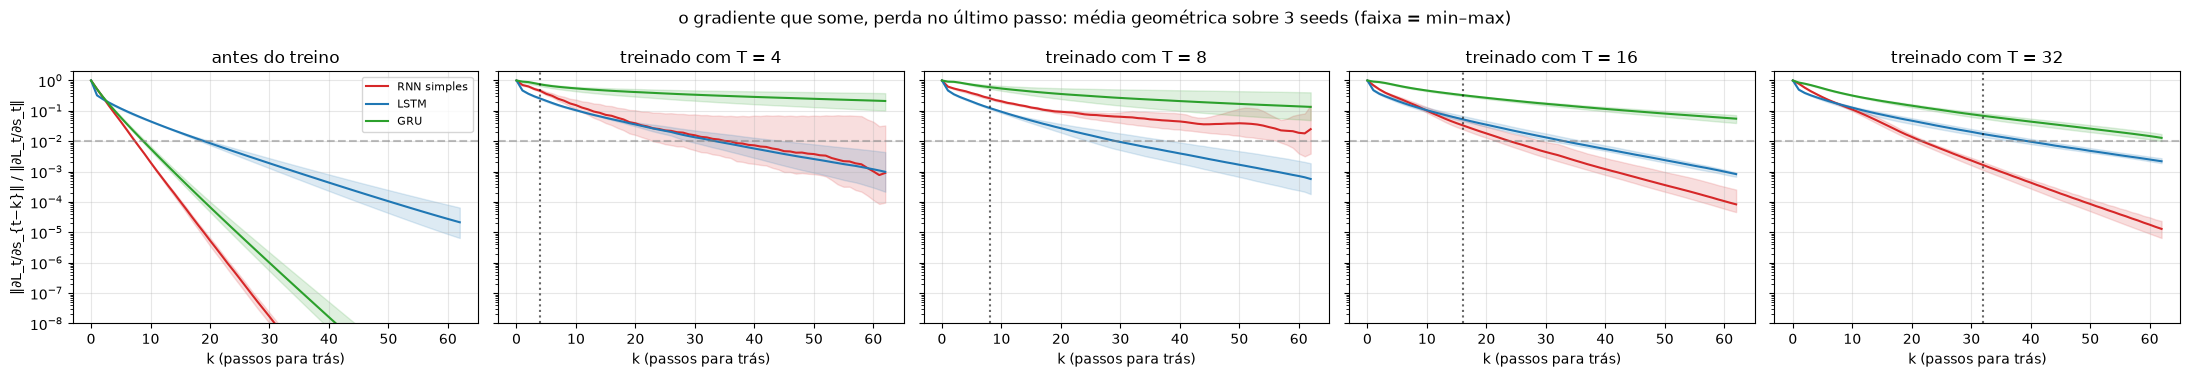

In [8]:
def horizon(curve, level=0.01):
    below = np.flatnonzero(curve < level)
    return int(below[0]) if len(below) else len(curve)


hz = pd.DataFrame([{"cell": c, "T": ("init" if mode == "init" else T), "regime": mode, "seed": s,
                    "horizonte (k, 1 %)": horizon(v[0]), "k=4": v[0][4], "k=8": v[0][8], "k=16": v[0][16],
                    "k=32": v[0][32]}
                   for (c, T, s, mode), v in grad.items() if mode != "last_observation"])
agg = hz.groupby(["cell", "T"], sort=False).agg({"horizonte (k, 1 %)": ["mean", "min", "max"], "k=4": "mean",
                                                 "k=8": "mean", "k=16": "mean", "k=32": "mean"})
agg.index = agg.index.set_levels([CELL_NAMES[c] for c in agg.index.levels[0]], level=0)
print("horizonte de gradiente e norma relativa ‖∂L/∂s_{t−k}‖ / ‖∂L/∂s_t‖ (média sobre 3 seeds; T = init: antes do treino)\n")
print(agg.to_string(float_format=lambda x: f"{x:.1e}" if abs(x) < 0.01 else f"{x:.3f}"))


def grad_curves_panel(ax, key_fn, title, T=None):
    for cell in CELLS:
        stack = np.stack([grad[key_fn(cell, s)][0] for s in SEEDS])
        log = np.log10(np.clip(stack, 1e-12, None))
        k = np.arange(stack.shape[1])
        ax.plot(k, 10 ** log.mean(axis=0), color=CELL_COLORS[cell], label=CELL_NAMES[cell])
        ax.fill_between(k, 10 ** log.min(axis=0), 10 ** log.max(axis=0), color=CELL_COLORS[cell], alpha=0.15)
    if T is not None:
        ax.axvline(T, color="k", linestyle=":", alpha=0.6)
    ax.axhline(0.01, color="gray", linestyle="--", alpha=0.5)
    ax.set_yscale("log")
    ax.set_ylim(1e-8, 2)
    ax.set_xlabel("k (passos para trás)")
    ax.set_title(title)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 1 + len(TBPTT), figsize=(22, 3.8), sharey=True)
grad_curves_panel(axes[0], lambda c, s: (c, 0, s, "init"), "antes do treino")
for ax, T in zip(axes[1:], TBPTT):
    grad_curves_panel(ax, lambda c, s, T=T: (c, T, s, "prediction"), f"treinado com T = {T}", T)
axes[0].set_ylabel("‖∂L_t/∂s_{t−k}‖ / ‖∂L_t/∂s_t‖")
axes[0].legend(fontsize=8)
fig.suptitle("o gradiente que some, perda no último passo: média geométrica sobre 3 seeds (faixa = min–max)")
plt.tight_layout()
plt.show()

**Antes do treino, a curva é a dos slides.** Com pesos aleatórios, a RNN simples cai abaixo de 1 % do sinal em 8 passos e chega a $10^{-9}$ em 32; a GRU (sem viés na porta de atualização, $z \approx 0{,}5$) é quase tão ruim (9 passos); a LSTM, com o viés do forget gate em 1, é a única com "esteira" desde o começo (20 passos; $10^{-3}$ em 32). Quem treina uma RNN simples começa com sinal praticamente nulo para dependências de mais de ~10 quadros.

**Depois do treino a curva é outra — e quem a define é a tarefa.** Os horizontes passam a 22–61 passos na RNN, 31–40 na LSTM e mais de 62 na GRU (que nunca cai abaixo de 1 % dentro da janela). A RNN treinada **não** tem gradiente menor que a LSTM: em $k = 16$ a norma relativa dela é 0,03–0,12, a da LSTM 0,04–0,07. E o horizonte não acompanha a qualidade: a GRU tem de longe o maior e a LSTM o menor, e as duas rastreiam igual; a RNN com $T = 32$ tem o horizonte mais curto dela (22) e é a melhor em coasting longo. A curva de um modelo treinado mede quanto ele *usa* o passado, não quanto *poderia* usar.

janelas por tamanho de buraco: {'g=1': 44, 'g=2-3': 50, 'g=4-7': 73, 'g=8-15': 62, 'g=16-31': 94, 'g=32-63': 53}


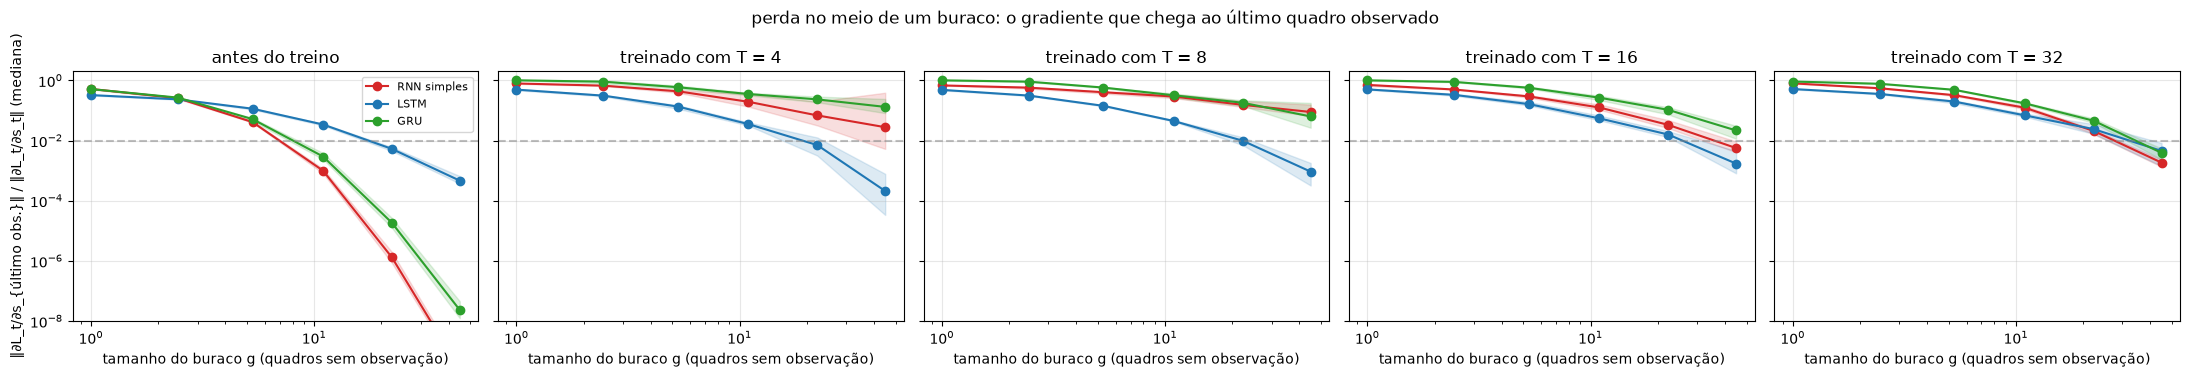


razão mediana no último quadro observado (média geométrica sobre 3 seeds):

                     g=1   g=2-3   g=4-7  g=8-15  g=16-31  g=32-63
cell        T                                                     
RNN simples 4    7.9e-01 6.7e-01 4.3e-01 1.9e-01  6.9e-02  2.8e-02
            8    6.8e-01 5.7e-01 4.0e-01 2.9e-01  1.5e-01  8.9e-02
            16   7.1e-01 5.0e-01 2.9e-01 1.3e-01  3.3e-02  5.6e-03
            32   8.0e-01 5.5e-01 3.2e-01 1.2e-01  2.1e-02  1.8e-03
LSTM        4    4.9e-01 3.1e-01 1.3e-01 3.5e-02  7.1e-03  2.1e-04
            8    4.8e-01 3.1e-01 1.4e-01 4.4e-02  9.9e-03  9.3e-04
            16   5.0e-01 3.3e-01 1.6e-01 5.5e-02  1.6e-02  1.7e-03
            32   5.2e-01 3.5e-01 2.0e-01 6.9e-02  2.4e-02  4.5e-03
GRU         4    1.0e+00 9.1e-01 5.9e-01 3.5e-01  2.3e-01  1.3e-01
            8    1.0e+00 9.1e-01 5.8e-01 3.2e-01  1.8e-01  6.3e-02
            16   1.0e+00 8.9e-01 5.7e-01 2.7e-01  1.1e-01  2.2e-02
            32   9.2e-01 7.7e-01 4.9e-01 1.7e-01  4.

In [9]:
# Perda dentro de um buraco: quanto do gradiente chega ao último quadro observado, por tamanho do buraco.
GAP_X = [np.sqrt(lo * hi) for lo, hi in GAP_BINS]


def gap_profile(last):
    out = []
    for lo, hi in GAP_BINS:
        sel = (last[:, 0] >= lo) & (last[:, 0] <= hi)
        out.append(np.median(last[sel, 1]) if sel.sum() >= 5 else np.nan)
    return np.array(out)


def gap_panel(ax, key_fn, title):
    for cell in CELLS:
        prof = np.stack([gap_profile(grad[key_fn(cell, s)][1]) for s in SEEDS])
        log = np.log10(np.clip(prof, 1e-12, None))
        ax.plot(GAP_X, 10 ** np.nanmean(log, axis=0), marker="o", color=CELL_COLORS[cell], label=CELL_NAMES[cell])
        ax.fill_between(GAP_X, 10 ** np.nanmin(log, axis=0), 10 ** np.nanmax(log, axis=0), color=CELL_COLORS[cell], alpha=0.15)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(1e-8, 2)
    ax.axhline(0.01, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("tamanho do buraco g (quadros sem observação)")
    ax.set_title(title)
    ax.grid(alpha=0.3)


n_gaps = pd.Series(grad[("rnn", 4, 0, "prediction")][1][:, 0]).apply(
    lambda g: next(k_label(lo, hi).replace("k", "g") for lo, hi in GAP_BINS if lo <= g <= hi)).value_counts()
print("janelas por tamanho de buraco:", n_gaps.reindex([k_label(lo, hi).replace("k", "g") for lo, hi in GAP_BINS]).to_dict())

fig, axes = plt.subplots(1, 1 + len(TBPTT), figsize=(22, 3.8), sharey=True)
gap_panel(axes[0], lambda c, s: (c, 0, s, "init"), "antes do treino")
for ax, T in zip(axes[1:], TBPTT):
    gap_panel(ax, lambda c, s, T=T: (c, T, s, "prediction"), f"treinado com T = {T}")
axes[0].set_ylabel("‖∂L_t/∂s_{último obs.}‖ / ‖∂L_t/∂s_t‖ (mediana)")
axes[0].legend(fontsize=8)
fig.suptitle("perda no meio de um buraco: o gradiente que chega ao último quadro observado")
plt.tight_layout()
plt.show()

def gap_summary(modes):
    rows = []
    for (c, T, s, mode), v in grad.items():
        if mode in modes:
            rows.append({"cell": CELL_NAMES[c], "T": "init" if mode == "init" else T, "seed": s,
                         **{k_label(lo, hi).replace("k", "g"): p for (lo, hi), p in zip(GAP_BINS, gap_profile(v[1]))}})
    table = pd.DataFrame(rows).groupby(["cell", "T"], sort=False).agg(
        lambda x: 10 ** np.nanmean(np.log10(np.clip(x, 1e-12, None))))
    return table.drop(columns="seed").to_string(float_format=lambda x: f"{x:.1e}")


print("\nrazão mediana no último quadro observado (média geométrica sobre 3 seeds):\n")
print(gap_summary({"prediction", "init"}))

**No meio de um buraco, ninguém olha muito para trás.** Com a perda num passo de coasting, o gradiente que chega ao último quadro observado cai a 2–5·10⁻² em buracos de 16–31 quadros nas três células treinadas com $T = 32$ (RNN 2,1·10⁻², LSTM 2,4·10⁻², GRU 4,6·10⁻²). Os modelos não carregam a última observação através do buraco porque **não precisam**: a cada passo de coasting a entrada é a própria previsão anterior, e o deslocamento dela — a velocidade — volta pela entrada. Seguir em frente é copiar a entrada para a saída, uma dependência de **um** passo.

É por isso que a RNN simples não quebra aqui: a tarefa, do jeito que a Parte 2 a montou, não tem a dependência longa que a mataria. A seção 5 a cria.

## 5. A sonda: tirar o atalho da entrada

No pipeline da Parte 2, durante a oclusão o modelo recebe a **própria previsão** como entrada, e a primeira componente da entrada é o deslocamento entre essa previsão e a caixa anterior — ou seja, a velocidade que ele mesmo acabou de prever volta pela entrada a cada passo. Para seguir em frente com velocidade constante basta copiar a entrada para a saída: uma dependência de **um** passo, que nenhum gradiente precisa atravessar.

A sonda (`MotionModel(coast_input="last_observation")`) troca só isso: durante o buraco entra a **última caixa observada, congelada** (deslocamento de entrada zero, flag de observação zero), e a saída passa a ser o deslocamento acumulado desde a última observação. A velocidade e o tempo decorrido agora só existem no **estado**: prever o quadro 20 de um buraco exige carregar, por 20 passos de recorrência, o que foi visto antes dele. Dados, seeds e avaliação são os mesmos da grade, e o treino também, com uma exceção: o *scheduled sampling* fica desligado — ele existe para expor o modelo às próprias previsões, que na sonda nunca entram; ligado, só injetaria a caixa congelada marcada como observada. $T \in \{4, 16, 32\}$.

sonda — IoU médio da previsão (média ± desvio sobre 3 seeds):

                      IoU k=0        IoU k=1      IoU k=2-3      IoU k=4-7     IoU k=8-15    IoU k=16-31    IoU k=32-63
cell        T                                                                                                          
GRU         4   0.795 ± 0.002  0.679 ± 0.004  0.608 ± 0.006  0.500 ± 0.008  0.324 ± 0.006  0.162 ± 0.002  0.080 ± 0.002
            16  0.788 ± 0.003  0.670 ± 0.007  0.605 ± 0.007  0.505 ± 0.006  0.345 ± 0.007  0.173 ± 0.009  0.080 ± 0.004
            32  0.784 ± 0.002  0.664 ± 0.004  0.604 ± 0.002  0.503 ± 0.004  0.328 ± 0.011  0.174 ± 0.010  0.080 ± 0.004
LSTM        4   0.796 ± 0.001  0.661 ± 0.012  0.596 ± 0.008  0.492 ± 0.002  0.332 ± 0.005  0.184 ± 0.010  0.079 ± 0.001
            16  0.789 ± 0.003  0.667 ± 0.006  0.608 ± 0.006  0.507 ± 0.006  0.340 ± 0.005  0.179 ± 0.008  0.079 ± 0.003
            32  0.783 ± 0.001  0.662 ± 0.003  0.604 ± 0.004  0.500 ± 0.006  0.324 ± 0.005  0.172 

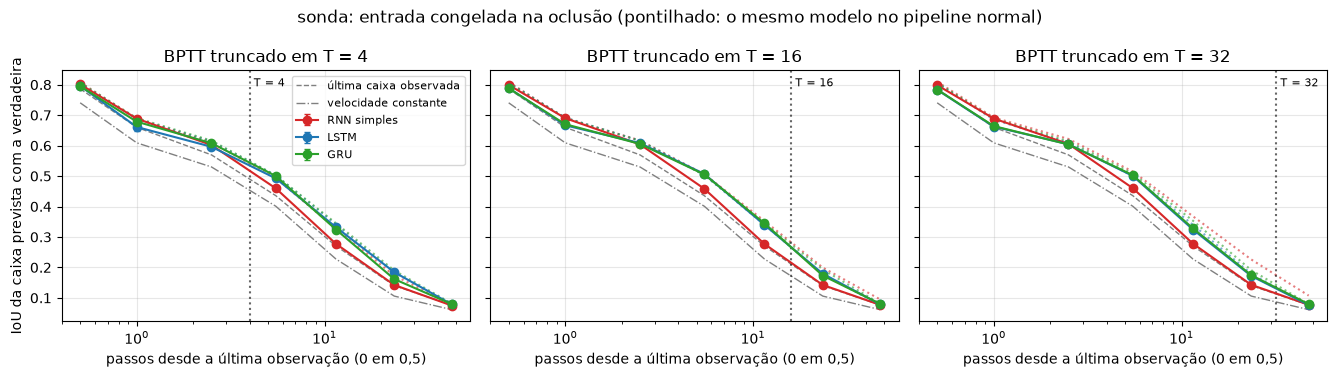

In [10]:
print("sonda — IoU médio da previsão (média ± desvio sobre 3 seeds):\n")
print(mean_std(probe_table, IOU_COLS).to_string())

iou_panels(probe_table, PROBE_T, "sonda: entrada congelada na oclusão (pontilhado: o mesmo modelo no pipeline normal)",
           ref=table)

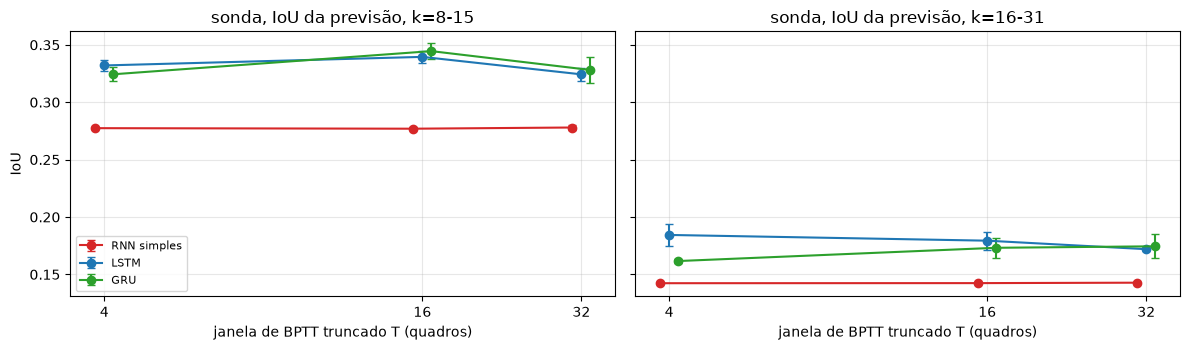

sonda, IoU em k = 8-15: diferença média ± desvio entre seeds pareadas

T                                     4                     16                    32
par                                                                                 
GRU − LSTM          -0.008 ± 0.003 (0/3)  +0.005 ± 0.006 (2/3)  +0.004 ± 0.016 (1/3)
GRU − RNN simples   +0.047 ± 0.007 (3/3)  +0.068 ± 0.006 (3/3)  +0.050 ± 0.009 (3/3)
LSTM − RNN simples  +0.055 ± 0.006 (3/3)  +0.063 ± 0.004 (3/3)  +0.046 ± 0.007 (3/3)

sonda, IoU em k = 16-31:

T                                     4                     16                    32
par                                                                                 
GRU − LSTM          -0.023 ± 0.009 (0/3)  -0.006 ± 0.012 (1/3)  +0.003 ± 0.010 (2/3)
GRU − RNN simples   +0.019 ± 0.002 (3/3)  +0.031 ± 0.008 (3/3)  +0.032 ± 0.010 (3/3)
LSTM − RNN simples  +0.042 ± 0.011 (3/3)  +0.037 ± 0.008 (3/3)  +0.029 ± 0.001 (3/3)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, col in zip(axes, ["IoU k=8-15", "IoU k=16-31"]):
    errorbar_by_T(ax, probe_table, col, PROBE_T)
    ax.set_title(col.replace("IoU ", "sonda, IoU da previsão, "))
axes[0].set_ylabel("IoU")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("sonda, IoU em k = 8-15: diferença média ± desvio entre seeds pareadas\n")
print(paired(probe_table, "IoU k=8-15", PROBE_T).to_string())
print("\nsonda, IoU em k = 16-31:\n")
print(paired(probe_table, "IoU k=16-31", PROBE_T).to_string())

**Sem o atalho, a RNN simples quebra — e quebra onde a teoria diz.** Com a velocidade guardada só no estado:

- até 1 quadro sem observação ela continua a melhor (0,798–0,801 em $k = 0$ e 0,688–0,690 em $k = 1$, contra 0,783–0,796 e 0,661–0,679 das células com portas);
- a partir de **4 quadros** ela fica para trás (0,46 contra 0,49–0,51 em $k$ = 4–7) e, de 8 em diante, ela é **exatamente a última caixa observada**: 0,277 contra 0,271 em $k$ = 8–15, 0,142 contra 0,140 em $k$ = 16–31. A velocidade vista antes do buraco se perdeu no estado. LSTM e GRU seguem com 0,32–0,35 em $k$ = 8–15 (+0,05 a +0,07 sobre a RNN, 3/3 seeds em todo $T$);
- **$T$ não muda nada** na RNN (0,277 / 0,277 / 0,278 em $k$ = 8–15 com $T$ = 4, 16 e 32): não é falta de janela de BPTT — mesmo com 32 passos de gradiente ela não aprende a segurar a velocidade. LSTM e GRU já aprendem com $T = 4$.

As células com portas ficam um pouco abaixo de si mesmas no pipeline normal (pontilhado) em coasting longo — prever o deslocamento acumulado desde a última observação é mais difícil que prever um passo —, mas a diferença para a RNN é de outra natureza: elas preveem um movimento, a RNN prevê que a pessoa parou.

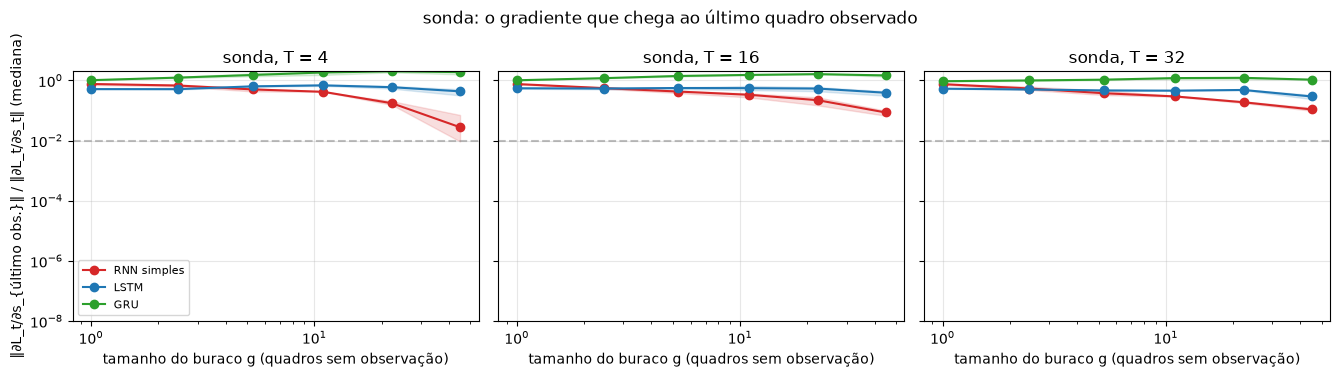

sonda — razão mediana no último quadro observado (média geométrica sobre 3 seeds):

                   g=1   g=2-3   g=4-7  g=8-15  g=16-31  g=32-63
cell        T                                                   
RNN simples 4  7.6e-01 6.8e-01 5.0e-01 4.2e-01  1.7e-01  2.8e-02
            16 7.6e-01 5.5e-01 4.3e-01 3.3e-01  2.2e-01  8.6e-02
            32 7.5e-01 5.4e-01 3.7e-01 2.9e-01  1.9e-01  1.1e-01
LSTM        4  5.1e-01 5.1e-01 6.3e-01 6.8e-01  5.9e-01  4.3e-01
            16 5.5e-01 5.4e-01 5.6e-01 5.5e-01  5.4e-01  3.9e-01
            32 5.3e-01 5.0e-01 4.6e-01 4.6e-01  4.8e-01  2.9e-01
GRU         4  1.0e+00 1.2e+00 1.5e+00 1.8e+00  2.0e+00  1.9e+00
            16 1.0e+00 1.2e+00 1.4e+00 1.5e+00  1.6e+00  1.5e+00
            32 9.4e-01 1.0e+00 1.1e+00 1.2e+00  1.2e+00  1.1e+00

sonda — rastreamento (média ± desvio sobre 3 seeds):

                  IDF1 treino       IDF1 val IDF1 combinado      IDSW / id       ids / id
cell        T                                           

In [12]:
fig, axes = plt.subplots(1, len(PROBE_T), figsize=(4.5 * len(PROBE_T), 3.8), sharey=True)
for ax, T in zip(axes, PROBE_T):
    gap_panel(ax, lambda c, s, T=T: (c, T, s, "last_observation"), f"sonda, T = {T}")
axes[0].set_ylabel("‖∂L_t/∂s_{último obs.}‖ / ‖∂L_t/∂s_t‖ (mediana)")
axes[0].legend(fontsize=8)
fig.suptitle("sonda: o gradiente que chega ao último quadro observado")
plt.tight_layout()
plt.show()

print("sonda — razão mediana no último quadro observado (média geométrica sobre 3 seeds):\n")
print(gap_summary({"last_observation"}))
print()

print("sonda — rastreamento (média ± desvio sobre 3 seeds):\n")
print(mean_std(probe_table, TRACK_COLS).to_string())

**E o gradiente conta a mesma história, agora no lugar certo.** Com a perda no meio do buraco, a razão no último quadro observado fica **plana** nas células com portas — 0,3–0,7 na LSTM e 0,9–2,0 na GRU, de buracos de 1 quadro a buracos de 32–63: com a porta fechada ($z \to 1$, $f \to 1$) o estado vira uma esteira, e na GRU o gradiente até *cresce* com o buraco, porque a velocidade guardada pesa mais quanto mais passos a saída a acumula. Na RNN a razão cai com o tamanho do buraco: 0,75 em $g = 1$, 0,3–0,4 em 8–15, 0,03–0,11 em 32–63. É o mecanismo dos slides 51–52: $\partial h_t / \partial h_{t-1} = \mathrm{diag}(1 - h_t^2)\,W_{hh}$ contrai a cada passo, e o que contrai o gradiente contrai também a informação — o estado da RNN esquece a velocidade no mesmo ritmo em que o gradiente deixa de chegar.

Uma ressalva: no modelo treinado a queda da RNN não é a catástrofe dos pesos aleatórios ($10^{-1}$ em 30 quadros, não $10^{-6}$), e mesmo assim a previsão dela em $k$ = 8–15 é a da caixa parada. A atenuação do gradiente é o sintoma que se mede; uma explicação compatível é que segurar um valor por 20 passos com $h_t = \tanh(W h_{t-1} + U x_t + b)$ exige ajustar $W$ perto da identidade, num regime quase linear, e que o treino, partindo de um sinal de $10^{-6}$ para essas distâncias, não chega lá — enquanto nas portas "segurar" é levar um único número ($z$ ou $f$) para perto de 1.

No rastreamento a sonda não muda o quadro (IDF1 combinado 0,603–0,623; a RNN de novo ~0,01–0,02 abaixo com $T$ = 4 e 16): ela foi feita para isolar a memória, não para rastrear melhor.

## 6. Estabilidade do treino

A norma do gradiente antes do *clipping* (média por época) e a perda de treino. Com BPTT truncado curto há mais passos de otimização por época (64 / $T$ por janela) — o *clipping* em norma 1 vale para todos.

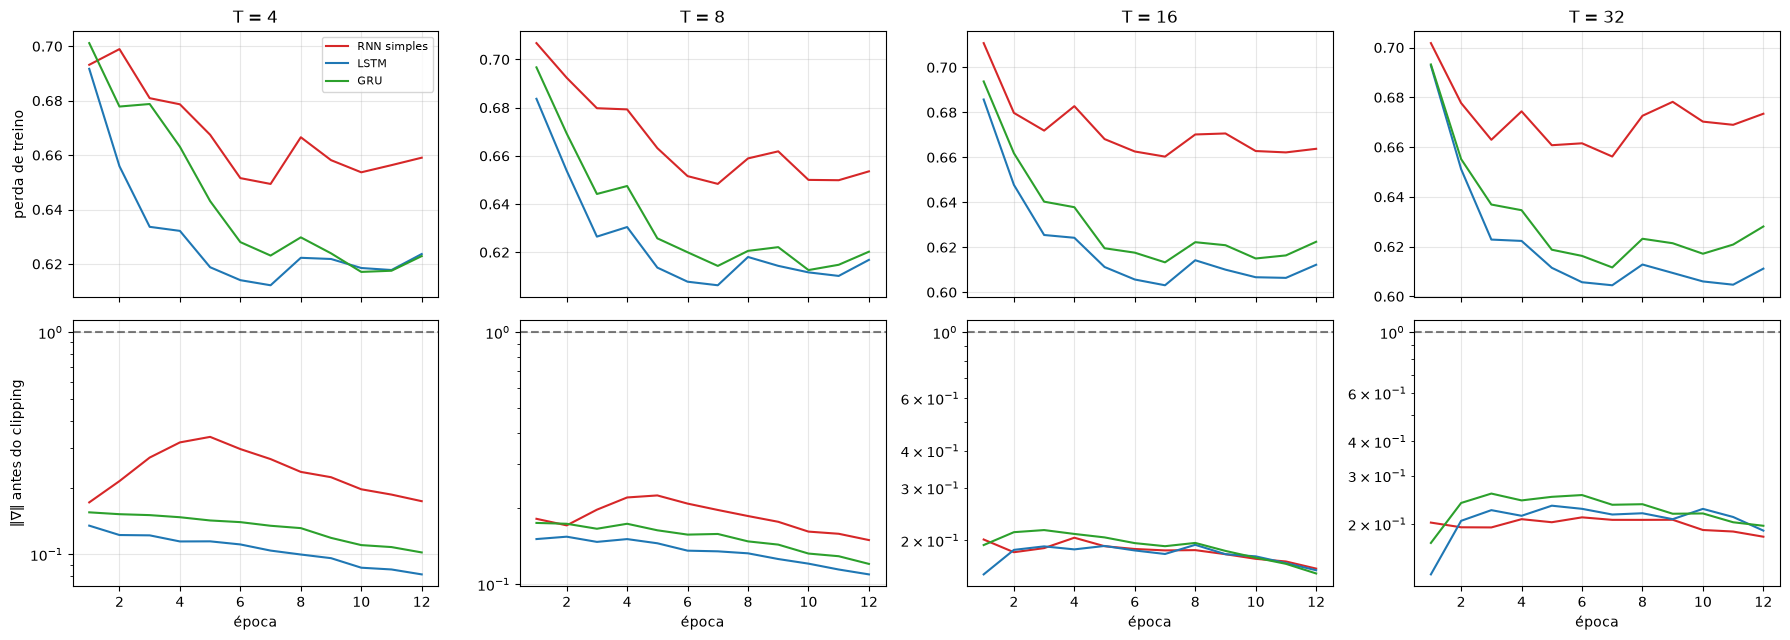

perda de treino e de validação na última época (média sobre 3 seeds):
     train_loss                      val_loss                     
T            4      8      16     32       4      8      16     32
cell                                                              
gru       0.623  0.620  0.622  0.628    0.977  0.976  0.966  0.964
lstm      0.624  0.617  0.612  0.611    0.972  0.964  0.962  0.967
rnn       0.659  0.654  0.664  0.673    0.977  0.964  0.954  0.951


In [13]:
hist = pd.DataFrame([{**h, "cell": r["cell"], "T": r["tbptt"], "seed": r["seed"]} for r in runs for h in r["history"]])

fig, axes = plt.subplots(2, len(TBPTT), figsize=(18, 6.5), sharex=True)
for col, T in enumerate(TBPTT):
    for cell in CELLS:
        part = hist[(hist.cell == cell) & (hist["T"] == T)].groupby("epoch")
        axes[0, col].plot(part["train_loss"].mean(), color=CELL_COLORS[cell], label=CELL_NAMES[cell])
        axes[1, col].plot(part["grad_norm"].mean(), color=CELL_COLORS[cell], label=CELL_NAMES[cell])
    axes[0, col].set_title(f"T = {T}")
    axes[1, col].axhline(DEFAULTS["clip_grad"], color="k", linestyle="--", alpha=0.5)
    axes[1, col].set_yscale("log")
    axes[1, col].set_xlabel("época")
    for ax in axes[:, col]:
        ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("perda de treino")
axes[1, 0].set_ylabel("‖∇‖ antes do clipping")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

last = hist[hist.epoch == hist.epoch.max()]
print("perda de treino e de validação na última época (média sobre 3 seeds):")
print(last.groupby(["cell", "T"])[["train_loss", "val_loss"]].mean().unstack().round(3).to_string())

Nenhum sinal de gradiente explodindo: a norma média antes do *clipping* fica entre 0,08 e 0,35 em todas as rodadas, abaixo do limiar 1. A RNN simples ajusta **pior o treino** (perda final 0,654–0,673 contra 0,611–0,628) e, na validação, empata com as outras (0,951–0,977 nas três células; a menor é a da RNN com $T$ = 16–32). A perda de treino sobe no fim de várias curvas por causa do *scheduled sampling* crescente (0 → 0,5), como na Parte 2.

## Conclusões da Parte 3

**Eixo 1 — a célula recorrente.** RNN simples (113 unidades), LSTM (54) e GRU (64), com ~13,8 mil parâmetros na célula, BPTT truncado em $T \in \{4, 8, 16, 32\}$ e 3 seeds; mais uma sonda que tira da entrada o atalho da velocidade ($T \in \{4, 16, 32\}$, 3 seeds). 63 modelos.

1. **No rastreamento, a célula importa pouco e $T$ quase nada.** LSTM e GRU empatam (IDF1 combinado 0,617–0,629); a RNN simples fica 0,010–0,017 abaixo da GRU em todo $T$, nas 3 seeds — pequeno, consistente e *não* ligado à memória longa (não muda com $T$, e a RNN é a melhor justamente em coasting longo com $T = 32$). A origem desse ponto fica em aberto para a galeria de falhas da Parte 4.
2. **Onde a RNN simples quebra.** No pipeline da Parte 2, só com $T$ curto em buracos longos ($T = 4$: a pior em $k$ = 16–31) — e com $T \geq 16$ ela passa as células com portas. Quando a tarefa exige carregar a velocidade no estado (a sonda), ela quebra a partir de ~4 quadros de buraco e, de 8 em diante, vira a caixa parada — com qualquer $T$. Até 1 quadro sem observação ela é a melhor nos dois cenários.
3. **Isso bate com a história do gradiente que some?** No mecanismo, sim — e só onde existe dependência longa. Antes do treino a curva é a dos slides (RNN: 1 % em 8 passos; a LSTM, com forget bias 1, em 20). Depois do treino o gradiente mede o uso do passado: no pipeline normal nenhuma célula olha para trás (a própria previsão, de volta na entrada, carrega a velocidade); na sonda as portas mantêm o gradiente plano por até 60 quadros e a RNN o deixa cair, no mesmo ritmo em que esquece a velocidade. E não é questão de truncar menos: janela de BPTT maior não salva a RNN na sonda.
4. **O que isso diz sobre a Parte 2.** A GRU da Parte 2 não é limitada pela memória: a tarefa como foi montada (deslocamento relativo, a própria previsão como entrada na oclusão) precisa de poucos passos, e uma RNN simples bem treinada faz o mesmo. A vantagem das portas aparece quando a informação tem de atravessar a oclusão *dentro do estado* — como na sonda, ou como seria com aparência (Trilha B). Mantemos a GRU como modelo final: empata com a LSTM e não depende de $T$.

Para a Parte 4: os 63 checkpoints estão em `results/3_ablation/` (`<célula>_T<T>_s<seed>.pt`; a sonda com sufixo `_mem`). A curva de $\|\partial \mathcal{L}_t / \partial h_{t-k}\|$ "da RNN simples com a do modelo com portas, na mesma janela" é a da seção 4 (pipeline normal) e a da seção 5 (sonda); `gradient_norm_through_time(..., full_state=True, per_sample=True)` reproduz qualquer recorte.

In [14]:
# ============================================================
# SALVA OS NÚMEROS DA PARTE 3
# ============================================================

def records(df, cols, how):
    return getattr(df.groupby(["cell", "T"])[cols], how)().round(4).reset_index().to_dict(orient="records")


summary = {
    "axis": "Eixo 1 -- celula recorrente x BPTT truncado",
    "param_budget_cell": PARAM_BUDGET,
    "hidden_sizes": {r["cell"]: r["hidden_size"] for r in runs},
    "train_cfg": DEFAULTS, "track_cfg": TRACK_CFG, "seeds": SEEDS, "tbptt": TBPTT, "probe_tbptt": PROBE_T,
    "tracking_mean": records(table, TRACK_COLS, "mean"),
    "tracking_std": records(table, TRACK_COLS, "std"),
    "iou_by_k_mean": records(table, IOU_COLS, "mean"),
    "iou_by_k_std": records(table, IOU_COLS, "std"),
    "probe_iou_by_k_mean": records(probe_table, IOU_COLS, "mean"),
    "probe_iou_by_k_std": records(probe_table, IOU_COLS, "std"),
    "probe_tracking_mean": records(probe_table, TRACK_COLS, "mean"),
    "gradient_horizon": hz.astype({"T": str}).groupby(["cell", "T"], sort=False)["horizonte (k, 1 %)"].mean().reset_index().to_dict(orient="records"),
    "runs_dir": OUT_DIR,
}

with open(os.path.join(RESULTS_DIR, "3_ablations.json"), "w", encoding="utf-8") as fh:
    json.dump(summary, fh, indent=2, ensure_ascii=False, default=float)

print(json.dumps({k: summary[k] for k in ["axis", "param_budget_cell", "hidden_sizes"]}, indent=2, ensure_ascii=False))

{
  "axis": "Eixo 1 -- celula recorrente x BPTT truncado",
  "param_budget_cell": 13824,
  "hidden_sizes": {
    "rnn": 113,
    "lstm": 54,
    "gru": 64
  }
}
